
#### Feature Descriptions:
###### age: Age of the patient (Numeric).
###### sex: Gender of the patient. Values: 1 = male, 0 = female.
###### cp: Chest pain type. Values: 0 = Typical angina, 1 = Atypical angina, 2 = Non-anginal pain, 3 = Asymptomatic.
###### trestbps: Resting Blood Pressure (in mm Hg) (Numeric).
###### chol: Serum Cholesterol level (in mg/dl) (Numeric).
###### fbs: Fasting blood sugar > 120 mg/dl. Values: 1 = true, 0 = false.
###### restecg: Resting electrocardiographic results. Values: 0 = Normal, 1 = ST-T wave abnormality, 2 = Left ventricular hypertrophy.
###### thalach: Maximum heart rate achieved (Numeric).
###### exang: Exercise-induced angina. Values: 1 = yes, 0 = no.
###### oldpeak: ST depression induced by exercise relative to rest (Numeric).
###### slope: Slope of the peak exercise ST segment. Values: 0 = Upsloping, 1 = Flat, 2 = Downsloping.
###### ca: Number of major vessels (0-3) colored by fluoroscopy. Values: 0, 1, 2, 3.
###### thal: Thalassemia types. Values: 1 = Normal, 2 = Fixed defect, 3 = Reversible defect.
###### target: Outcome variable (heart attack risk). Values: 1 = more chance of heart attack, 0 = less chance of heart attack.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('C:\\Brototype\\ML_learn\\ML_projects\\Paper3\\MODULE10\\raw_merged_heart_dataset.csv')
# C:\Brototype\ML_learn\ML_projects\Paper3\MODULE10\raw_merged_heart_dataset.csv

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2181 entries, 0 to 2180
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2181 non-null   int64  
 1   sex       2181 non-null   int64  
 2   cp        2181 non-null   int64  
 3   trestbps  2181 non-null   str    
 4   chol      2181 non-null   str    
 5   fbs       2181 non-null   str    
 6   restecg   2181 non-null   str    
 7   thalachh  2181 non-null   str    
 8   exang     2181 non-null   str    
 9   oldpeak   2181 non-null   float64
 10  slope     2181 non-null   str    
 11  ca        2181 non-null   str    
 12  thal      2181 non-null   str    
 13  target    2181 non-null   int64  
dtypes: float64(1), int64(4), str(9)
memory usage: 238.7 KB


In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
2176,60,1,0,140,207,0,0,138,1,1.9,2,1,3,0
2177,46,1,0,140,311,0,1,120,1,1.8,1,2,3,0
2178,59,1,3,134,204,0,1,162,0,0.8,2,2,2,0
2179,54,1,1,154,232,0,0,164,0,0.0,2,1,2,0
2180,53,1,0,110,335,0,1,143,1,3.0,1,1,3,0


In [6]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps        str
chol            str
fbs             str
restecg         str
thalachh        str
exang           str
oldpeak     float64
slope           str
ca              str
thal            str
target        int64
dtype: object

In [7]:
df.duplicated().sum()

np.int64(1287)

In [8]:
df = df.drop_duplicates().reset_index(drop=True)

In [9]:
for column in df:
    print(column,':', df[column].unique())

age : [63 37 41 56 57 44 52 54 48 49 64 58 50 66 43 69 59 42 61 40 71 51 65 53
 46 45 39 47 62 34 35 29 55 60 67 68 74 76 70 38 77 28 30 31 32 33 36]
sex : [1 0]
cp : [3 2 1 0]
trestbps : <StringArray>
['145', '130', '120', '140', '172', '150', '110', '135', '160', '105', '125',
 '142', '155', '104', '138', '128', '108', '134', '122', '115', '118', '100',
 '124',  '94', '112', '102', '152', '101', '132', '148', '178', '129', '180',
 '136', '126', '106', '156', '170', '146', '117', '200', '165', '174', '192',
 '144', '123', '154', '114', '164',  '98', '190',   '?', '113',  '92', '158']
Length: 55, dtype: str
chol : <StringArray>
['233', '250', '204', '236', '354', '192', '294', '263', '199', '168',
 ...
 '603', '404', '518', '285', '279', '388', '336', '491', '331', '393']
Length: 202, dtype: str
fbs : <StringArray>
['1', '0', '?']
Length: 3, dtype: str
restecg : <StringArray>
['0', '1', '2', '?']
Length: 4, dtype: str
thalachh : <StringArray>
['150', '187', '172', '178', '163', '148', 

In [10]:
df= df.replace('?', np.nan)

In [11]:
df.isnull().sum()

age           0
sex           0
cp            0
trestbps      1
chol         22
fbs           8
restecg       1
thalachh      1
exang         1
oldpeak       0
slope       189
ca          290
thal        265
target        0
dtype: int64

In [12]:
for column in df.columns[:-1]:
    df[column] = pd.to_numeric(df[column], errors='coerce')
    df[column] = df[column].fillna(df[column].median())

In [13]:
df.shape

(894, 14)

In [14]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
count,894.000000,894.000000,894.000000,894.000000,894.000000,894.000000,894.000000,894.000000,894.000000,894.000000,894.000000,894.00000,894.000000,894.000000
mean,52.302013,0.697987,1.665548,131.949664,249.092841,0.124161,0.572707,145.993289,0.325503,0.913758,1.633110,0.47651,3.338926,0.444072
std,9.205776,0.459388,1.126391,17.527605,56.337502,0.329950,0.757770,23.700255,0.468825,1.105398,0.573451,0.87199,1.585314,0.497140
min,28.000000,0.000000,0.000000,92.000000,85.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,45.000000,0.000000,1.000000,120.000000,212.000000,0.000000,0.000000,130.000000,0.000000,0.000000,1.000000,0.00000,3.000000,0.000000
50%,53.000000,1.000000,2.000000,130.000000,244.000000,0.000000,0.000000,150.000000,0.000000,0.500000,2.000000,0.00000,3.000000,0.000000
75%,59.000000,1.000000,3.000000,140.000000,277.000000,0.000000,1.000000,163.000000,1.000000,1.500000,2.000000,1.00000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.00000,7.000000,1.000000


In [15]:
df['target'].value_counts()

target
0    497
1    397
Name: count, dtype: int64

In [16]:
def outlier_checker(column):
    q1=column.quantile(0.25)
    q3=column.quantile(0.75)
    IQR= q3-q1
    lower_bound = q1 - IQR * 1.5
    outer_bound = q3 + IQR * 1.5
    return df[(column > outer_bound) | (column < lower_bound)]


In [17]:
for col in ['age', 'trestbps', 'chol', 'thalachh', 'oldpeak']:
    outliers = outlier_checker(df[col])
    if len(outliers) !=0:
        print(col, ':', outliers)


trestbps :      age  sex  cp  trestbps   chol  fbs  restecg  thalachh  exang  oldpeak  \
8     52    1   2     172.0  199.0  1.0      1.0     162.0    0.0      0.5   
101   59    1   3     178.0  270.0  0.0      0.0     145.0    0.0      4.2   
110   64    0   0     180.0  325.0  0.0      1.0     154.0    1.0      0.0   
202   68    1   2     180.0  274.0  1.0      0.0     150.0    1.0      1.6   
222   56    0   0     200.0  288.0  1.0      0.0     133.0    1.0      4.0   
240   59    0   0     174.0  249.0  0.0      1.0     143.0    1.0      0.0   
247   54    1   1     192.0  283.0  0.0      0.0     195.0    0.0      0.0   
259   66    0   0     178.0  228.0  1.0      1.0     165.0    1.0      1.0   
265   55    0   0     180.0  327.0  0.0      2.0     117.0    1.0      3.4   
337   39    1   1     190.0  241.0  0.0      0.0     106.0    0.0      0.0   
374   45    0   1     180.0  244.0  0.0      0.0     180.0    0.0      0.0   
386   46    1   3     180.0  280.0  0.0      1.0     

In [18]:
df['sex'].value_counts()

sex
1    624
0    270
Name: count, dtype: int64

<Axes: xlabel='sex', ylabel='count'>

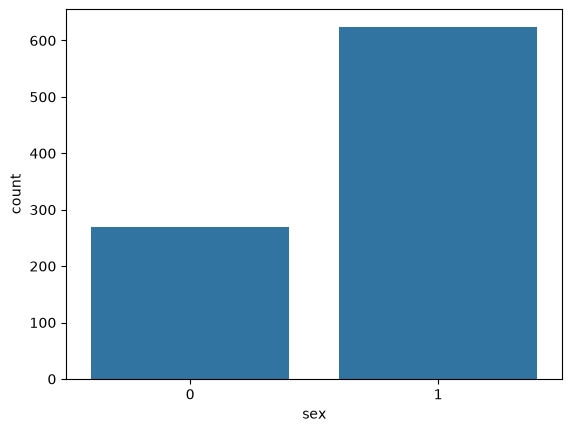

In [19]:
sns.countplot(x=df['sex'])

<Axes: xlabel='thal', ylabel='count'>

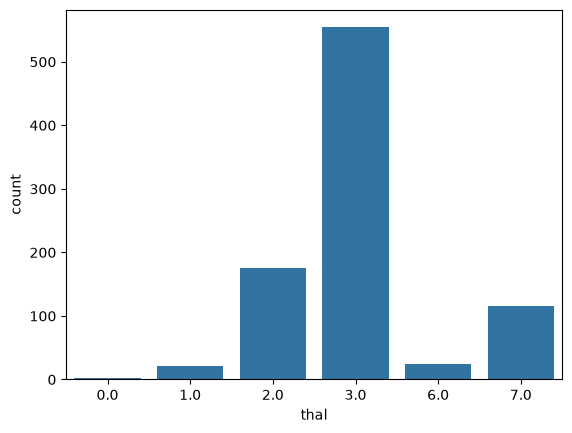

In [20]:
sns.countplot(x=df['thal'])

<Axes: xlabel='target', ylabel='count'>

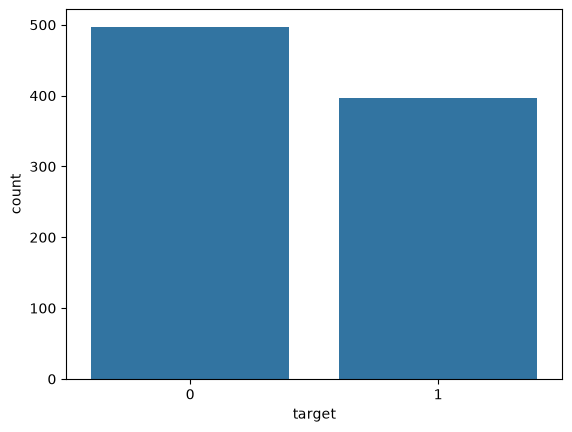

In [21]:
sns.countplot(x=df['target'])

In [22]:
df['cp'].unique()

array([3, 2, 1, 0])